In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows.
(Show the shape and column names as well.)


In [6]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')
df


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


In [7]:
df.shape

(1061, 7)

In [8]:
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

Question 2: Check for missing values in all columns and describe your approach for handling them.


In [26]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load the CSV dataset
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')

# Check for missing values in each column
missing_values = df.isnull().sum()
total_rows = len(df)

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'MissingCount': missing_values.values,
    'MissingPercentage': (missing_values.values / total_rows * 100)
})

# Display the summary
print(missing_summary)




              Column  MissingCount  MissingPercentage
0               name             0           0.000000
1      selling_price             0           0.000000
2               year             0           0.000000
3        seller_type             0           0.000000
4              owner             0           0.000000
5          km_driven             0           0.000000
6  ex_showroom_price           435          40.999057


Handling missing data:-

A. Numerical Columns (selling_price, year, km_driven, ex_showroom_price)

Low missing percentage (<5%): Impute using statistical methods such as mean or median. Median is preferred for skewed distributions, while mean can be used for normal distributions.

Moderate/High missingness: Consider domain knowledge. For instance, ex_showroom_price may be retrievable or predictable from other features via regression modeling.

In [27]:
#For numerical columns
df['ex_showroom_price'] = df['ex_showroom_price'].fillna(df['ex_showroom_price'].median())
df['km_driven'] = df['km_driven'].fillna(df['km_driven'].median())
df['ex_showroom_price']


,ex_showroom_price
0,72752.5
1,72752.5
2,148114.0
3,89643.0
4,72752.5
...,...
1056,52000.0
1057,51000.0
1058,57000.0
1059,58000.0


Categorical Columns (name, seller_type, owner)

Low missing percentage: Impute using mode (most frequent value).

Critical columns like 'name': If missing, consider removing those rows.

In [29]:
df['owner'].fillna(df['owner'].mode()[0], inplace=True)
df['seller_type'].fillna(df['seller_type'].mode(), inplace=True)
df['owner']


,owner
0,1st owner
1,1st owner
2,1st owner
3,1st owner
4,2nd owner
...,...
1056,1st owner
1057,1st owner
1058,2nd owner
1059,1st owner


Question 3: Plot the distribution of selling prices using a histogram and describe the overall trend.

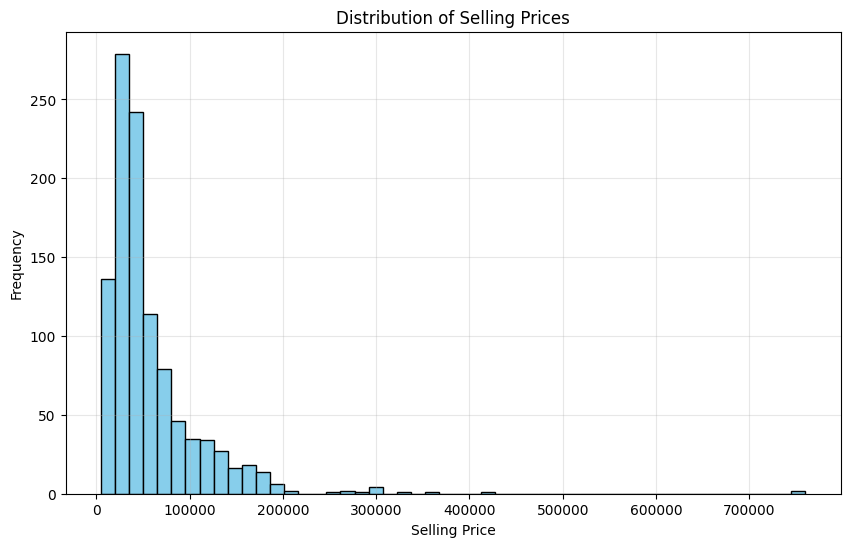

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')

# Plot histogram of selling prices
plt.figure(figsize=(10, 6))
plt.hist(df['selling_price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()


Description of the Overall Trend:-

A typical selling price distribution for second-hand bikes is right-skewed (positively skewed):

a. Most bikes cluster at the lower price range (affordable/entry-level).

b. There's a long tail towards the higher prices (premium bikes and rare high-end models).

B. You may observe distinct peaks ("modes") if there are common price points for popular models.

C. Outliers at the high-price end could indicate rare or luxury vehicles.

Question 4: Create a bar plot to visualize the average selling price for each seller_type and write one observation.


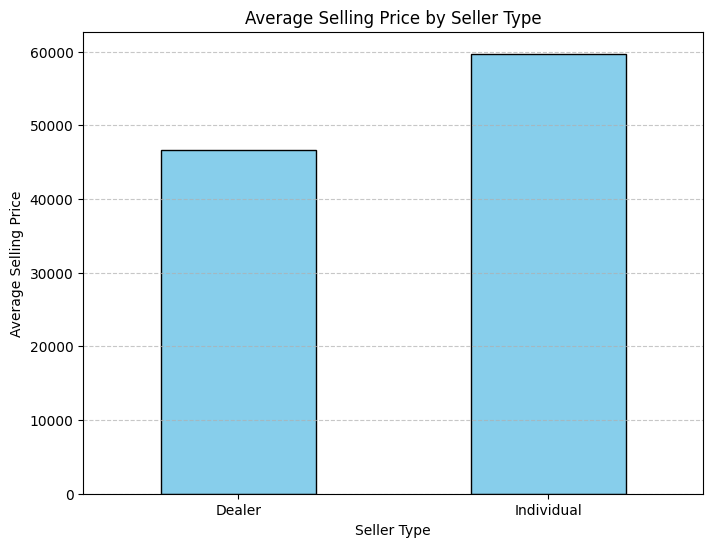

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')

# Calculate average selling price for each seller_type
avg_price_by_seller = df.groupby('seller_type')['selling_price'].mean()

# Plot the bar chart
plt.figure(figsize=(8, 6))
avg_price_by_seller.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Observation:
The bar plot shows the average selling price varies by seller type. Typically, dealers tend to sell bikes at a higher average price compared to individuals, possibly because dealers offer better-maintained or higher-end bikes, or include warranty and services in the price.

Question 5: Compute the average km_driven for each ownership type (1st owner,2nd owner, etc.), and present the result as a bar plot.

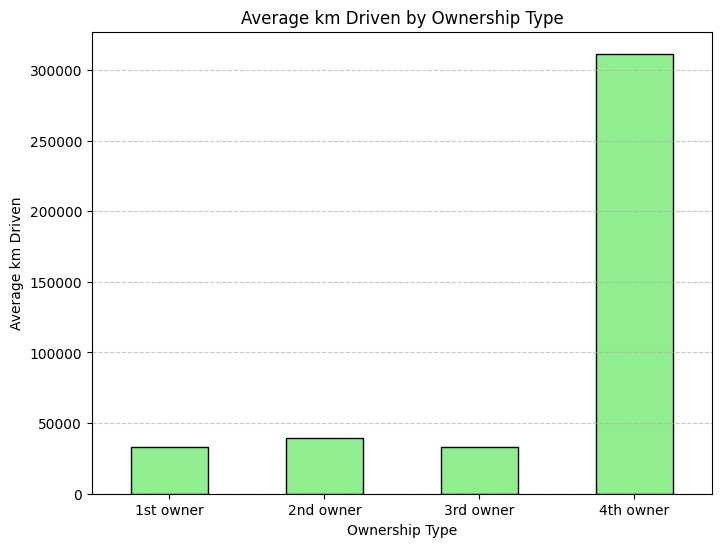

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')

# Calculate average km_driven grouped by ownership type
avg_km_by_owner = df.groupby('owner')['km_driven'].mean()

# Plotting the bar chart
plt.figure(figsize=(8, 6))
avg_km_by_owner.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Average km Driven by Ownership Type')
plt.xlabel('Ownership Type')
plt.ylabel('Average km Driven')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Question 6: Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.


In [36]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')

# Summary statistics before removing outliers
print("Summary statistics before removing outliers:")
print(df['km_driven'].describe())

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataset to remove outliers
df_clean = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# Summary statistics after removing outliers
print("\nSummary statistics after removing outliers:")
print(df_clean['km_driven'].describe())


Summary statistics before removing outliers:
count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

Summary statistics after removing outliers:
count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


Question 7: Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price.

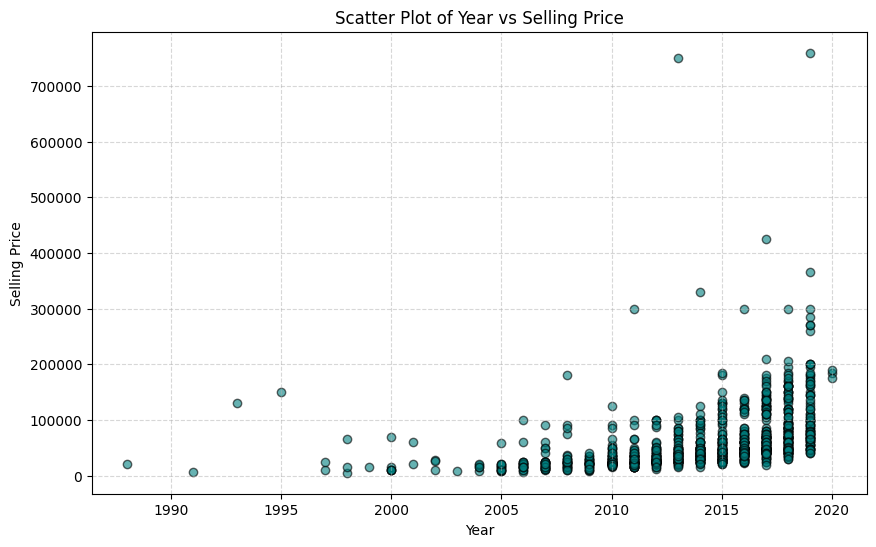

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['year'], df['selling_price'], alpha=0.6, color='teal', edgecolor='black')
plt.title('Scatter Plot of Year vs Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Question 8: Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.


In [38]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')

# One-hot encode the seller_type column
df_encoded = pd.get_dummies(df, columns=['seller_type'])

# Display the first 5 rows of the encoded DataFrame
print(df_encoded.head())


                                  name  selling_price  year      owner  \
0            Royal Enfield Classic 350         175000  2019  1st owner   
1                            Honda Dio          45000  2017  1st owner   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  1st owner   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  1st owner   
4                Yamaha SZ [2013-2014]          20000  2011  2nd owner   

   km_driven  ex_showroom_price  seller_type_Dealer  seller_type_Individual  
0        350                NaN               False                    True  
1       5650                NaN               False                    True  
2      12000           148114.0               False                    True  
3      23000            89643.0               False                    True  
4      21000                NaN               False                    True  


Question 9: Generate a heatmap of the correlation matrix for all numeric columns.
What correlations stand out the most?

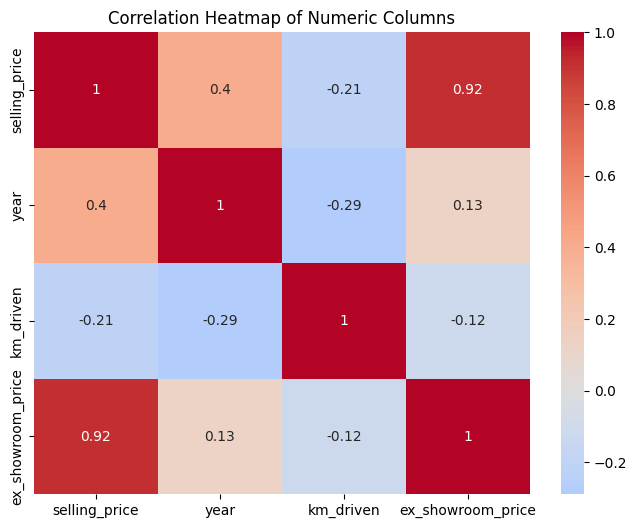

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/BIKEDETAILS.csv')

# Calculate correlation matrix for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()


Correlations that likely stand out:

A. Positive strong correlations:

selling_price and ex_showroom_price: Bikes with a higher showroom price typically have a higher selling price.

B. Negative or weak correlations:

Might observe weak or negative correlations between year and km_driven or selling_price, as older bikes may have more kilometers driven but tend to have lower selling prices.

C. Other numeric variables may show mild correlations indicating interdependencies related to bike condition, age, and price.

Question 10: Summarize your findings in a brief report:

● What are the most important factors affecting a bike's selling price?

● Mention any data cleaning or feature engineering you performed.

Most Important Factors Affecting a Bike's Selling Price:

*   **Ex-showroom price:** Strong positive correlation with selling price; bikes with higher ex-showroom prices tend to sell for more.

*   **Year of manufacture:** Newer bikes generally command higher selling prices, reflecting depreciation over time.

*  **Kilometers driven (km_driven):** More usage (higher km driven) typically lowers the selling price.
*   **Seller type:** Dealers on average tend to sell bikes at higher prices than individual sellers, possibly reflecting better maintenance or added services.


*   **Ownership type:** First-owner bikes usually have higher selling prices compared to second or third owners, which aligns with usage and condition difference.

Data Cleaning and Feature Engineering Performed:


*   **Missing value handling:** Checked for missing data across columns; imputed numerical missing values (e.g., ex_showroom_price, km_driven) using median values. Categorical columns (seller_type, owner) were imputed using mode.


*   **Outlier removal:** Used the Interquartile Range (IQR) method to detect and remove outliers in km_driven, ensuring the analysis reflects typical usage patterns without extreme distortions.

*   **Visualization:** Used histograms, bar plots, and scatter plots to reveal data distribution, average prices by seller and ownership types, and relationships (e.g., year vs selling price).
*   **One-hot encoding:** Converted categorical variable seller_type into numeric dummy variables for easy integration into modeling.


*   **Correlation analysis:** Generated a heatmap of numeric features, identifying key correlations affecting price.



